In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32") / 255.0)[..., None]

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=1)

# Сохранение весов
model.save_weights('ultra.weights.h5')
print("Веса сохранены в ultra.weights.h5")

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Точность на MNIST (тест):", acc)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 102ms/step - accuracy: 0.9284 - loss: 0.2417 - val_accuracy: 0.9812 - val_loss: 0.0622
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9792 - loss: 0.0698 - val_accuracy: 0.9865 - val_loss: 0.0463
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 99ms/step - accuracy: 0.9845 - loss: 0.0495 - val_accuracy: 0.9887 - val_loss: 0.0402
Веса сохранены в ultra.weights.h5
Точность на MNIST (тест): 0.9883999824523926


In [2]:

import cv2
from scipy.ndimage import center_of_mass, shift

def preprocess_paint_png(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Файл не прочитан. Проверьте имя/путь.")

    # сглаживание
    img = cv2.GaussianBlur(img, (3,3), 0)

    # авто-инверсия
    if img.mean() > 127:
        img = 255 - img

    _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ищем рамку цифры
    coords = cv2.findNonZero(bw)
    if coords is None:
        raise ValueError("На изображении не найдено пикселей цифры (после порога).")

    x, y, w, h = cv2.boundingRect(coords)
    digit = bw[y:y+h, x:x+w]

    # делаем квадрат с полем
    size = max(w, h) + 8
    square = np.zeros((size, size), dtype=np.uint8)
    x_off = (size - w) // 2
    y_off = (size - h) // 2
    square[y_off:y_off+h, x_off:x_off+w] = digit

    resized = cv2.resize(square, (20,20), interpolation=cv2.INTER_AREA)
    padded = np.pad(resized, ((4,4),(4,4)), mode="constant")

    cy, cx = center_of_mass(padded)
    if np.isnan(cx) or np.isnan(cy):
        raise ValueError("Проблема с центром масс (пустое изображение после обработки).")

    shift_y = 14 - cy
    shift_x = 14 - cx
    centered = shift(padded, shift=(shift_y, shift_x), order=0, mode="constant", cval=0)

    # нормирование
    x_in = (centered.astype("float32") / 255.0).reshape(1, 28, 28, 1)

    return x_in, centered

Saving 2.png to 2.png
Файл: 2.png


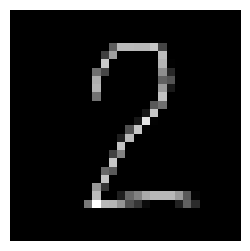

Распознано: 2
Уверенность: 0.44848769903182983
Вероятности по классам:
0 : 0.04633631929755211
1 : 0.16472500562667847
2 : 0.44848769903182983
3 : 0.04768293350934982
4 : 0.030167367309331894
5 : 0.03501499444246292
6 : 0.03937910124659538
7 : 0.05671757087111473
8 : 0.08686692267656326
9 : 0.04462205618619919


In [3]:
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print("Файл:", fname)

x_in, dbg = preprocess_paint_png(fname)

# показываем, что реально подаётся в сеть
plt.figure(figsize=(3,3))
plt.imshow(dbg, cmap="gray")
plt.axis("off")
plt.show()

pred = model.predict(x_in, verbose=0)[0]
digit = int(np.argmax(pred))
conf = float(np.max(pred))

print("Распознано:", digit)
print("Уверенность:", conf)

print("Вероятности по классам:")
for i, p in enumerate(pred):
    print(i, ":", float(p))